In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models, datasets
from sklearn.metrics import accuracy_score, confusion_matrix


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import seaborn as sns

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Classificador StyleGAN2/Real

In [5]:
class VGG16Classifier(nn.Module):
    def __init__(self, num_classes=2, freeze_features=True):
        super().__init__()
        self.vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        if freeze_features:
            for param in self.vgg16.features.parameters():
                param.requires_grad = False

        in_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.vgg16(x)

checkpoint_path = '/home/vandrade/src/notebooks/odin_cross-domain_morphs/checkpoints/stylegan2-classifier/best_vgg16_weights_stylegan2.pt'
model = VGG16Classifier(num_classes=2, freeze_features=True).to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))

<All keys matched successfully>

In [6]:
transformer_vgg16 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

### Conjunto de Teste: 167 fakes vs 167 reais

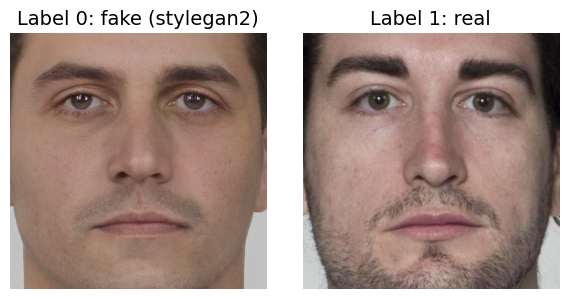

In [7]:
dataset_vis = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan2_real/test', transform=None)
classes = dataset_vis.classes

img_real = None
img_stylegan2 = None

for img, label in dataset_vis:
    if label == 0 and img_stylegan2 is None:
        img_stylegan2 = img
        label_stylegan2 = label
    elif label == 1 and img_real is None:
        img_real = img
        label_real = label
    
    if img_real is not None and img_stylegan2 is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].set_title(f"Label {label_stylegan2}: {classes[label_stylegan2]} (stylegan2)", fontsize=14)
axes[0].imshow(img_stylegan2)
axes[0].axis("off")

axes[1].set_title(f"Label {label_real}: {classes[label_real]}", fontsize=14)
axes[1].imshow(img_real)
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [8]:
stg2_test_set = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan2_real/test', transform=transformer_vgg16)
stg2_test_loader = DataLoader(dataset=stg2_test_set, batch_size=32, shuffle=False)

print(f"classes: {stg2_test_set.classes}")

classes: ['fake', 'real']


Acurácia: 0.9940


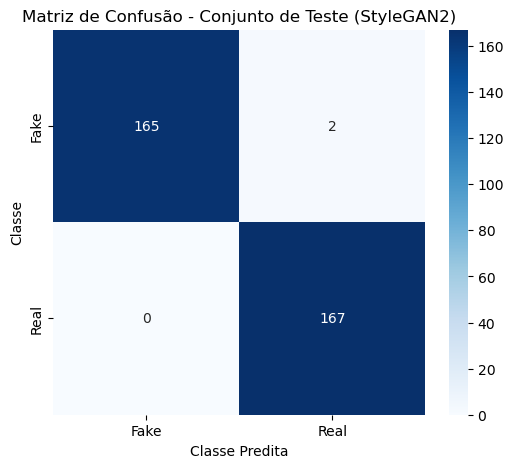

In [9]:
model.eval()

all_stg2_preds = []
all_stg2_targets = []

with torch.inference_mode():
    for X, y in stg2_test_loader:
        X,y = X.to(device), y.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_stg2_preds.extend(preds.cpu().numpy())
        all_stg2_targets.extend(y.cpu().numpy())

acc_stg2 = accuracy_score(all_stg2_targets, all_stg2_preds)
print(f"Acurácia: {acc_stg2:.4f}")

cm = confusion_matrix(all_stg2_targets, all_stg2_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake', 'Real'], 
            yticklabels=['Fake', 'Real'])
plt.xlabel('Classe Predita')
plt.ylabel('Classe')
plt.title('Matriz de Confusão - Conjunto de Teste (StyleGAN2)')
plt.show()

# ODIN

### 1) Temperature Scaling

$$S_i(x; T) = \frac{\exp(f_i(x) / T)}{\sum_{j=1}^{N} \exp(f_j(x) / T)}$$

$$\hat{y} = \arg\max_i S_i(x; T)$$

### 2) Perturbação da Entrada

$$L = -\log S_{\hat{y}}(x; T)$$

$$\tilde{x} = x - \epsilon \cdot \text{sign}(\nabla_x L)$$

### 3) Inferência com ODIN
Forward pass da imagem perturbada $\tilde{x}$

$$C(\tilde{x}) = \max_i S_i(\tilde{x}; T)$$

### 4) Decisão
A partir de um threshold $\delta$, a decisão é definida como:

$$
\text{Decisão} =  \begin{cases}
  \text{In-Distribution}, & \text{se } C(\tilde{x}) \ge \delta \\
  \text{Out-of-Distribution}, & \text{se } C(\tilde{x}) < \delta
\end{cases}
$$

In [10]:
def apply_odin(image, model, temperature=1000.0, epsilon=0.0014):
    image = image.to(device)
    image.requires_grad = True #habilitar calculo do grad na imagem

    # forward pass
    outputs = model(image)

    # f_i(x)/temperatura
    outputs = outputs / temperature
    predicted_class = outputs.argmax(dim=1)

    # cross-entropy loss = -log(Softmax).
    loss = F.cross_entropy(outputs, predicted_class)

    # backward pass (gradiente)
    model.zero_grad() #remove acumulo dos gradientes
    loss.backward() #calcula dLoss/dPixels

    # sign(grad_x)
    gradient_sign = torch.sign(image.grad)

    # perturbação x~
    perturbed_image = image - epsilon * gradient_sign

    return perturbed_image.detach() #retorno da imagem (com requires_grad = False)

In [11]:
def get_confidence_odin(image, model, T=1000, eps=0.0014):
    image = apply_odin(image, model, temperature=T, epsilon=eps)

    with torch.no_grad():
      outputs = model(image) / T
      probs = F.softmax(outputs, dim=1)
      max_prob, _ = torch.max(probs, dim=1)

    return max_prob.detach().cpu().tolist()

def get_confidence(image, model):
    with torch.no_grad():
      outputs = model(image)
      probs = F.softmax(outputs, dim=1)
      max_prob, _ = torch.max(probs, dim=1)

    return max_prob.detach().cpu().tolist()

In [12]:
def extract_odin_scores(model, dataloader, device, T=2.0, eps=0.0014, only_fakes=False):
    model.eval()
    scores = []
    
    for images, labels in dataloader:
        #remover imagens reais de domínio ood
        if only_fakes:
            mask = (labels == 0)
            if not mask.any():
                continue
            images = images[mask]
            
        images = images.to(device)
        batch_scores = get_confidence_odin(images, model, T, eps)
        scores.extend(batch_scores)
        
    return np.array(scores)

In [13]:
def get_threshold_fpr95(id_scores):
    # threshold definido para o valor onde 5% das imagens ID ficam abaixo e 95% acima
    return np.percentile(id_scores, 5)

def evaluate_accuracies(id_scores, ood_scores, threshold, criterion_name="Personalizado"):
    acc_id = np.mean(id_scores >= threshold) * 100
    acc_ood = np.mean(ood_scores < threshold) * 100
    
    print(f"[{criterion_name}] Limiar: {threshold:.4f} | Acc ID: {acc_id:.2f}% | Acc OOD: {acc_ood:.2f}%")
    return acc_id, acc_ood

In [14]:
def plot_odin_histogram(id_scores, ood_scores, T, eps, id_name="ID", ood_name="OOD", threshold=None):
    plt.figure(figsize=(8, 5))
    
    sns.histplot(id_scores, color='blue', alpha=0.5, label=id_name, stat='density', bins=30, kde=True, line_kws={'linewidth': 2})
    sns.histplot(ood_scores, color='red', alpha=0.5, label=ood_name, stat='density', bins=30, kde=True, line_kws={'linewidth': 2})
    
    if threshold is not None:
        plt.axvline(x=threshold, color='black', linestyle='--', linewidth=2.5, label=f'Limiar FPR95 ({threshold:.4f})')
        
    plt.title(f'Detecção ODIN (T={T}, eps={eps})')
    plt.xlabel('Confiança ODIN')
    plt.ylabel('Densidade')
    plt.legend()
    plt.show()

# Out-of-Distribution (OOD)

In [25]:
epsilons = [0.001, 0.002, 0.003, 0.004]

## Inferência MipGan2

### Conjunto de Teste: 167 fakes vs 167 reais

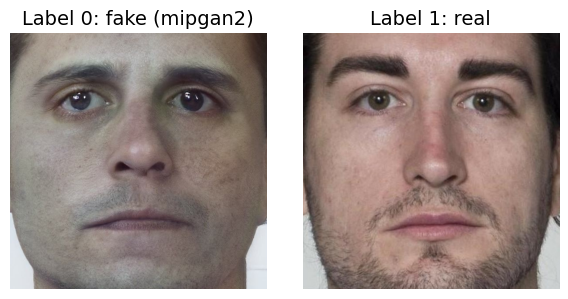

In [16]:
dataset_vis = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/mipgan2_real/test', transform=None)
classes = dataset_vis.classes

img_real = None
img_mipgan2 = None

for img, label in dataset_vis:
    if label == 0 and img_mipgan2 is None:
        img_mipgan2 = img
        label_mipgan2 = label
    elif label == 1 and img_real is None:
        img_real = img
        label_real = label
    
    if img_real is not None and img_mipgan2 is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].set_title(f"Label {label_mipgan2}: {classes[label_mipgan2]} (mipgan2)", fontsize=14)
axes[0].imshow(img_mipgan2)
axes[0].axis("off")

axes[1].set_title(f"Label {label_real}: {classes[label_real]}", fontsize=14)
axes[1].imshow(img_real)
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [17]:
mip2_test_set = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/mipgan2_real/test', transform=transformer_vgg16)
mip2_test_loader = DataLoader(dataset=mip2_test_set, batch_size=32, shuffle=False)

print(f"classes: {mip2_test_set.classes}")

classes: ['fake', 'real']


Acurácia: 0.7904


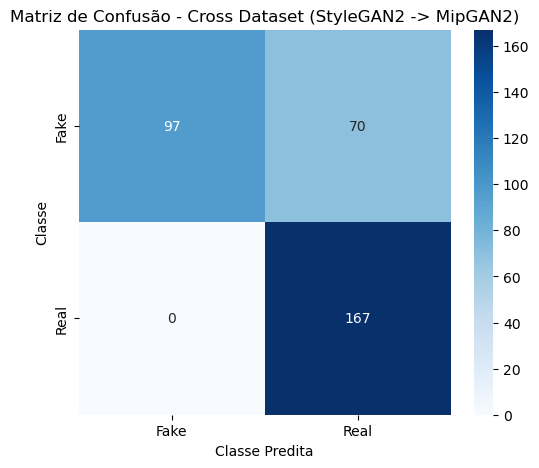

In [18]:
model.eval()

all_mip2_preds = []
all_mip2_targets = []

with torch.inference_mode():
    for X, y in mip2_test_loader:
        X,y = X.to(device), y.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_mip2_preds.extend(preds.cpu().numpy())
        all_mip2_targets.extend(y.cpu().numpy())

acc_mip2 = accuracy_score(all_mip2_targets, all_mip2_preds)
print(f"Acurácia: {acc_mip2:.4f}")

cm = confusion_matrix(all_mip2_targets, all_mip2_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake', 'Real'], 
            yticklabels=['Fake', 'Real'])
plt.xlabel('Classe Predita')
plt.ylabel('Classe')
plt.title('Matriz de Confusão - Cross Dataset (StyleGAN2 -> MipGAN2)')
plt.show()

[FPR95] Limiar: 0.9696 | Acc ID: 94.91% | Acc OOD: 38.92%


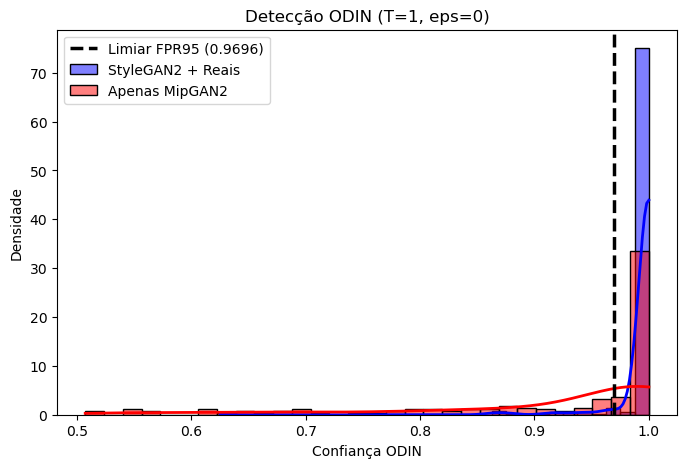



[FPR95] Limiar: 0.5030 | Acc ID: 94.91% | Acc OOD: 37.13%


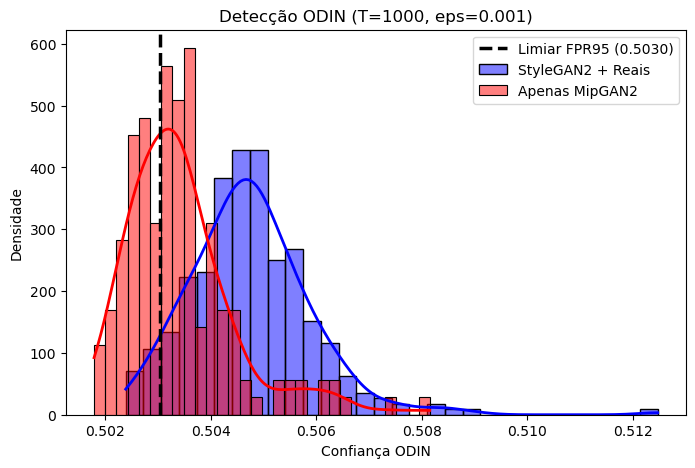



[FPR95] Limiar: 0.5044 | Acc ID: 94.91% | Acc OOD: 34.13%


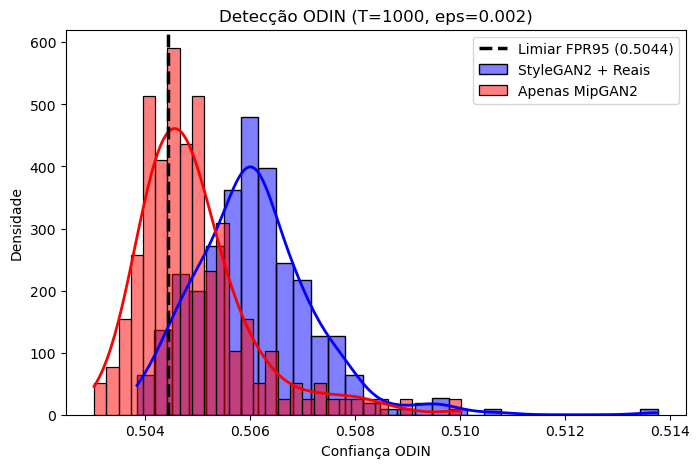



[FPR95] Limiar: 0.5054 | Acc ID: 94.91% | Acc OOD: 31.74%


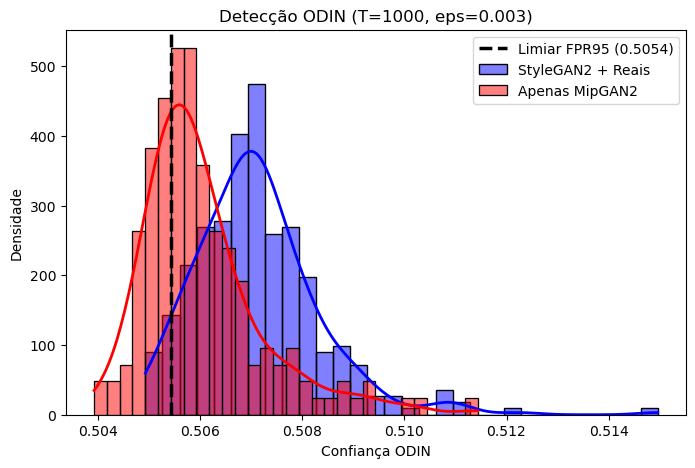



[FPR95] Limiar: 0.5062 | Acc ID: 94.91% | Acc OOD: 28.14%


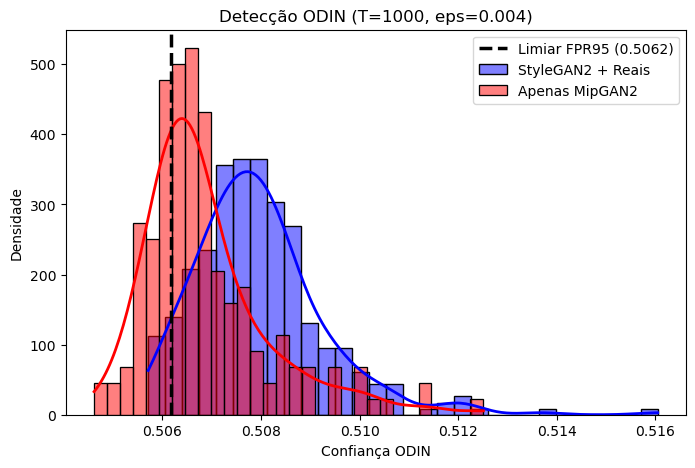

In [27]:
id_conf = extract_odin_scores(model, stg2_test_loader, device, T=1.0, eps=0, only_fakes=False)
ood_conf = extract_odin_scores(model, mip2_test_loader, device, T=1.0, eps=0, only_fakes=True)
threshold_95 = get_threshold_fpr95(id_conf)
acc_id, acc_ood = evaluate_accuracies(id_conf, ood_conf, threshold_95, criterion_name="FPR95")   
plot_odin_histogram(
    id_conf, 
    ood_conf, 
    T=1, 
    eps=0, 
    id_name="StyleGAN2 + Reais", 
    ood_name="Apenas MipGAN2",
    threshold=threshold_95
)
print("\n")

for eps in epsilons:
    id_conf = extract_odin_scores(model, stg2_test_loader, device, T=1000, eps=eps, only_fakes=False)
    ood_conf = extract_odin_scores(model, mip2_test_loader, device, T=1000, eps=eps, only_fakes=True)
    
    threshold_95 = get_threshold_fpr95(id_conf)
    
    acc_id, acc_ood = evaluate_accuracies(id_conf, ood_conf, threshold_95, criterion_name="FPR95")
    
    plot_odin_histogram(
        id_conf, 
        ood_conf, 
        T=1000, 
        eps=eps, 
        id_name="StyleGAN2 + Reais", 
        ood_name="Apenas MipGAN2",
        threshold=threshold_95
    )
    print("\n")

# Inferência StyleGan3

### Conjunto de Teste: 167 fakes vs 167 reais

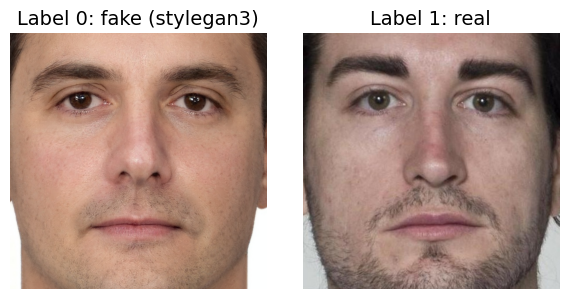

In [20]:
dataset_vis = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan3_real/test', transform=None)
classes = dataset_vis.classes

img_real = None
img_stylegan3 = None

for img, label in dataset_vis:
    if label == 0 and img_stylegan3 is None:
        img_stylegan3 = img
        label_stylegan3 = label
    elif label == 1 and img_real is None:
        img_real = img
        label_real = label
    
    if img_real is not None and img_stylegan3 is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].set_title(f"Label {label_stylegan3}: {classes[label_stylegan3]} (stylegan3)", fontsize=14)
axes[0].imshow(img_stylegan3)
axes[0].axis("off")

axes[1].set_title(f"Label {label_real}: {classes[label_real]}", fontsize=14)
axes[1].imshow(img_real)
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [21]:
stg3_test_set = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan3_real/test', transform=transformer_vgg16)
stg3_test_loader = DataLoader(dataset=stg3_test_set, batch_size=32, shuffle=False)

print(f"classes: {stg3_test_set.classes}")

classes: ['fake', 'real']


Acurácia: 0.8563


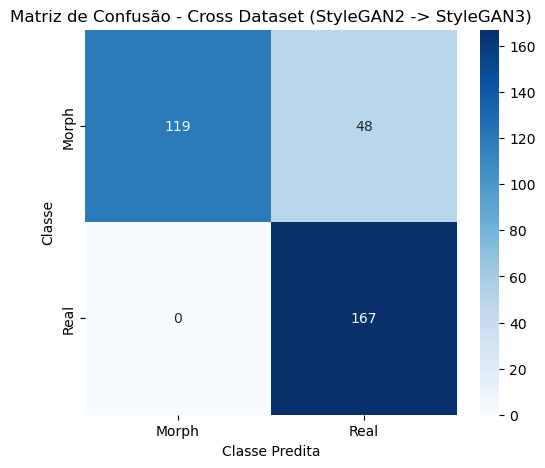

In [22]:
model.eval()

all_stg3_preds = []
all_stg3_targets = []

with torch.inference_mode():
    for X, y in stg3_test_loader:
        X,y = X.to(device), y.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_stg3_preds.extend(preds.cpu().numpy())
        all_stg3_targets.extend(y.cpu().numpy())

acc_stg3 = accuracy_score(all_stg3_targets, all_stg3_preds)
print(f"Acurácia: {acc_stg3:.4f}")

cm = confusion_matrix(all_stg3_targets, all_stg3_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Morph', 'Real'], 
            yticklabels=['Morph', 'Real'])
plt.xlabel('Classe Predita')
plt.ylabel('Classe')
plt.title('Matriz de Confusão - Cross Dataset (StyleGAN2 -> StyleGAN3)')
plt.show()

[FPR95] Limiar: 0.9696 | Acc ID: 94.91% | Acc OOD: 46.11%


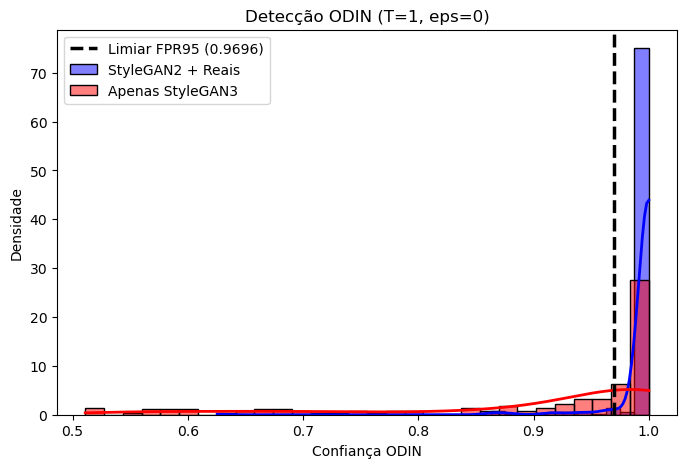



[FPR95] Limiar: 0.5030 | Acc ID: 94.91% | Acc OOD: 52.10%


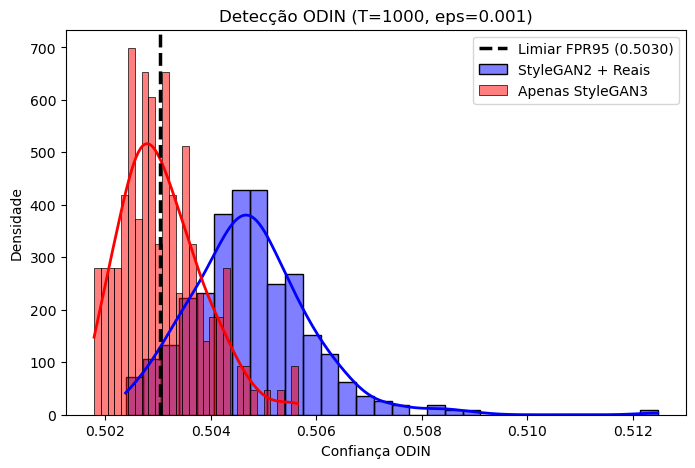



[FPR95] Limiar: 0.5044 | Acc ID: 94.91% | Acc OOD: 48.50%


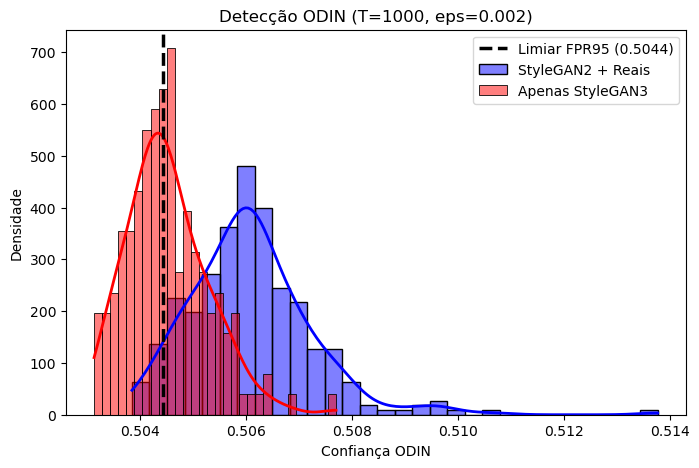



[FPR95] Limiar: 0.5054 | Acc ID: 94.91% | Acc OOD: 47.90%


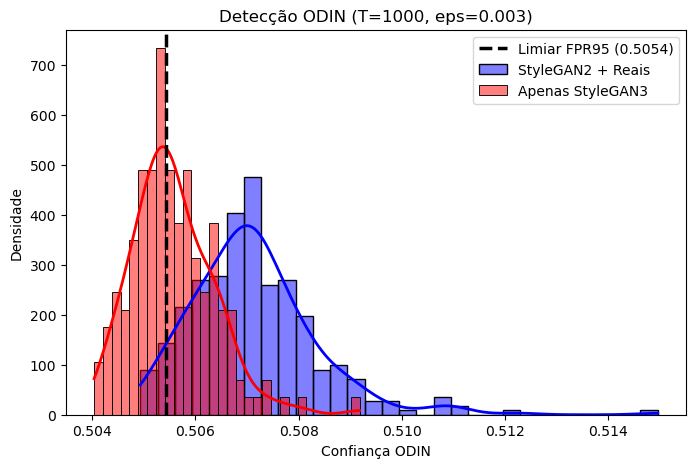



[FPR95] Limiar: 0.5062 | Acc ID: 94.91% | Acc OOD: 41.32%


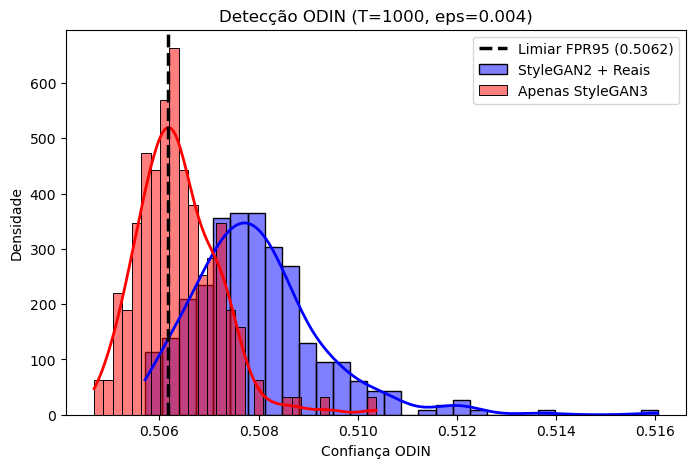

In [28]:
id_conf = extract_odin_scores(model, stg2_test_loader, device, T=1.0, eps=0, only_fakes=False)
ood_conf = extract_odin_scores(model, stg3_test_loader, device, T=1.0, eps=0, only_fakes=True)
threshold_95 = get_threshold_fpr95(id_conf)
acc_id, acc_ood = evaluate_accuracies(id_conf, ood_conf, threshold_95, criterion_name="FPR95")   
plot_odin_histogram(
    id_conf, 
    ood_conf, 
    T=1, 
    eps=0, 
    id_name="StyleGAN2 + Reais", 
    ood_name="Apenas StyleGAN3",
    threshold=threshold_95
)
print("\n")

for eps in epsilons:
    id_conf = extract_odin_scores(model, stg2_test_loader, device, T=1000, eps=eps, only_fakes=False)
    ood_conf = extract_odin_scores(model, stg3_test_loader, device, T=1000, eps=eps, only_fakes=True)
    
    threshold_95 = get_threshold_fpr95(id_conf)
    
    acc_id, acc_ood = evaluate_accuracies(id_conf, ood_conf, threshold_95, criterion_name="FPR95")
    
    plot_odin_histogram(
        id_conf, 
        ood_conf, 
        T=1000, 
        eps=eps, 
        id_name="StyleGAN2 + Reais", 
        ood_name="Apenas StyleGAN3",
        threshold=threshold_95
    )
    print("\n")